In [1]:
import numpy as np
import seaborn as sns
import pandas as pd


In [13]:
#knn implemenation from scratch --binary classfication

class MyKNNClassifier():
    def __init__(self,k=3):
        self.k=k
    def _euclidean_distance(self,x1,x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    def fit(self,X,y):
        self.X_train=X
        self.y_train=y

    def _predict_one(self,x):
        distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]
        knn_indices = np.argsort(distances)[:self.k]

        knn_classes = [self.y_train[i] for i in knn_indices]

        majority_class = np.argmax(np.bincount(knn_classes))
        return majority_class

    def predict(self,X):
        y_pred = [self._predict_one(x) for x in X]
        return np.array(y_pred)

In [14]:
X_train = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7]
])

y_train = np.array([0, 0, 0, 1, 1])

X_test = np.array([
    [2, 2],
    [6, 6]
])
model = MyKNNClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

[0 1]


<Axes: xlabel='x1', ylabel='x2'>

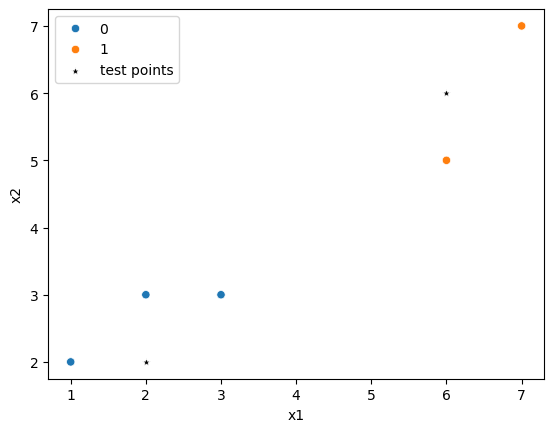

In [15]:
X_train_df=pd.DataFrame(X_train,columns=["x1","x2"])
X_train_df["label"]=y_train
sns.scatterplot(
    data=X_train_df,
    x="x1",
    y="x2",
    hue="label"
)
X_test_df=pd.DataFrame(X_test,columns=["x1","x2"])
sns.scatterplot(
    data=X_test_df,
    x="x1",
    y="x2",
    color="black",
    marker="*",
    label="test points"
)
    